# Mutual Fund SIP Analysis Project
## Python Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# display all columns 
pd.set_option( 'display.max_columns', None)

## Step 1: Load the Dataset
#### In this step, we load the Excel workbook containing the Investors, Fund Master, and SIP Transactions data.

In [13]:
investors = pd.read_excel(file_path, sheet_name="Investors")

funds = pd.read_excel(file_path, sheet_name="Fund_Master")

transactions = pd.read_excel(file_path, sheet_name="SIP_Transactions")

## Step 2: Data Understanding

Before performing any analysis, we inspect the datasets to understand their structure, data types, missing values, and duplicate records.

In [14]:
investors.head()

investors.shape

investors.columns

investors.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Investor_ID               1000 non-null   object
 1   Gender                    1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Marital_Status            1000 non-null   object
 4   Occupation                1000 non-null   object
 5   Annual_Income             1000 non-null   int64 
 6   City                      1000 non-null   object
 7   State                     1000 non-null   object
 8   Risk_Profile              1000 non-null   object
 9   Investment_Goal           1000 non-null   object
 10  Investment_Horizon_Years  1000 non-null   int64 
 11  Investor_Segment          1000 non-null   object
dtypes: int64(3), object(9)
memory usage: 93.9+ KB


In [16]:
print("Investors:", investors.shape)
print("Funds:", funds.shape)
print("Transactions:", transactions.shape)

Investors: (1000, 12)
Funds: (5, 5)
Transactions: (12000, 8)


In [17]:
print(investors.columns)
print(funds.columns)
print(transactions.columns)

Index(['Investor_ID', 'Gender', 'Age', 'Marital_Status', 'Occupation',
       'Annual_Income', 'City', 'State', 'Risk_Profile', 'Investment_Goal',
       'Investment_Horizon_Years', 'Investor_Segment'],
      dtype='object')
Index(['Fund_ID', 'Fund_Name', 'Fund_Category', 'AMC', 'Expected_Return_%'], dtype='object')
Index(['Transaction_ID', 'Investor_ID', 'Date', 'Fund_ID', 'Fund_Name',
       'SIP_Amount', 'NAV', 'Units_Allocated'],
      dtype='object')


### Business Insight

- No missing values were found.
- No duplicate records were found.
- The datasets are clean and ready for analysis.

# Exploratory Data Analysis (EDA)

## Business Question 1

How many investors, funds, and SIP transactions are present in the dataset?

### Why are we analyzing this?

These KPIs provide a high-level overview of the dataset and help understand the scale of business operations.

In [18]:
# Total number of investors
total_investors = investors["Investor_ID"].nunique()

print("Total Investors:", total_investors)

Total Investors: 1000


In [19]:
# Total number of mutual funds
total_funds = funds["Fund_ID"].nunique()

print("Total Funds:", total_funds)

Total Funds: 5


In [24]:
# Total SIP Transactions
total_transactions = transactions["Transaction_ID"].nunique()

print("Total Transactions:", total_transactions)

Total Transactions: 12000


In [25]:
# Total Investment Amount
total_investment = transactions["SIP_Amount"].sum()

print("Total Investment:", total_investment)

Total Investment: 94926000


In [26]:
# Average SIP Amount
average_sip = transactions["SIP_Amount"].mean()

print("Average SIP Amount:", round(average_sip, 2))

Average SIP Amount: 7910.5


In [27]:
print("Minimum SIP:", transactions["SIP_Amount"].min())

print("Maximum SIP:", transactions["SIP_Amount"].max())

Minimum SIP: 1000
Maximum SIP: 20000


### Business Insight

- The dataset contains 1000 investors.
- There are 5 mutual funds.
- The total SIP investment is 94926000.
- The minimum SIP amount is ₹1000.
- The maximum SIP amount is ₹20000.

## Business Question 2

What is the gender distribution of investors?

### Why are we analyzing this?

This analysis helps understand whether the investor base is balanced between male and female investors.

In [28]:
#Count investors by gender
gender_count = investors["Gender"].value_counts()

print(gender_count)

Gender
Male      511
Female    489
Name: count, dtype: int64


In [29]:
# What is the age distribution of investors?
print(investors["Age"].describe())

count    1000.000000
mean       40.684000
std        11.372048
min        22.000000
25%        31.000000
50%        40.000000
75%        51.000000
max        60.000000
Name: Age, dtype: float64


### Business Insight

The investor base is almost equally distributed between male and female investors, indicating balanced participation across genders.

## Business Question 4

Which risk profile has the highest number of investors?

### Why are we analyzing this?

Risk profile analysis helps the company understand investors' risk appetite and recommend suitable mutual funds.

In [32]:
risk_profile = investors["Risk_Profile"].value_counts()

print(risk_profile)

Risk_Profile
Moderate        343
Conservative    331
Aggressive      326
Name: count, dtype: int64


Create bar chart


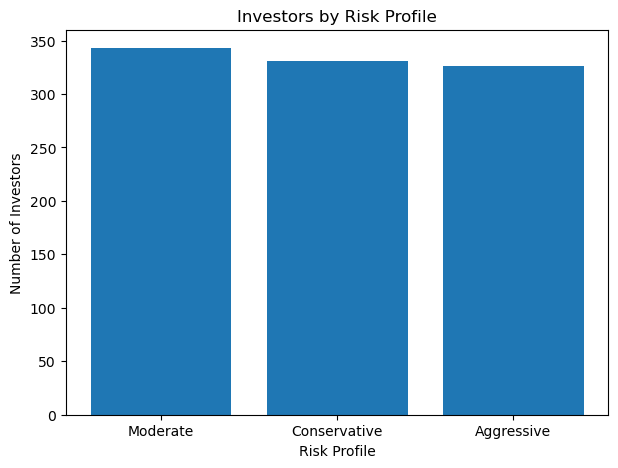

In [33]:
print('Create bar chart')
plt.figure(figsize=(7,5))

plt.bar(risk_profile.index, risk_profile.values)

plt.title("Investors by Risk Profile")
plt.xlabel("Risk Profile")
plt.ylabel("Number of Investors")

plt.show()

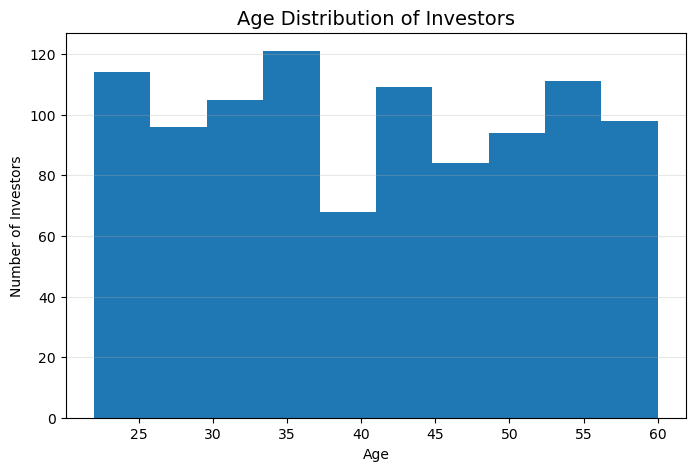

In [20]:
plt.figure(figsize=(8,5))

plt.hist(investors["Age"], bins=10)
plt.title("Age Distribution of Investors", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Investors")
plt.grid(axis='y', alpha=0.3)

plt.show()

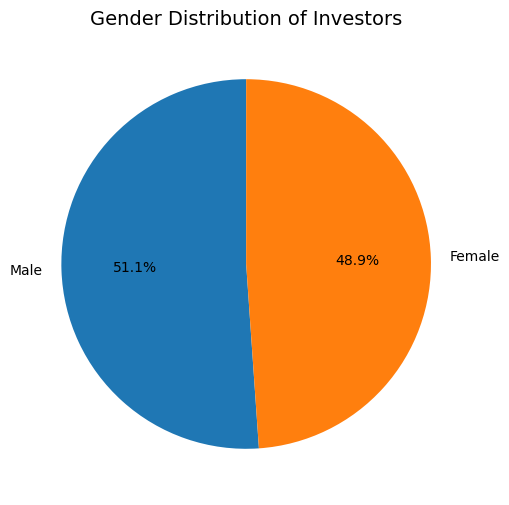

In [21]:
gender_count = investors["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution of Investors", fontsize=14)

plt.show()

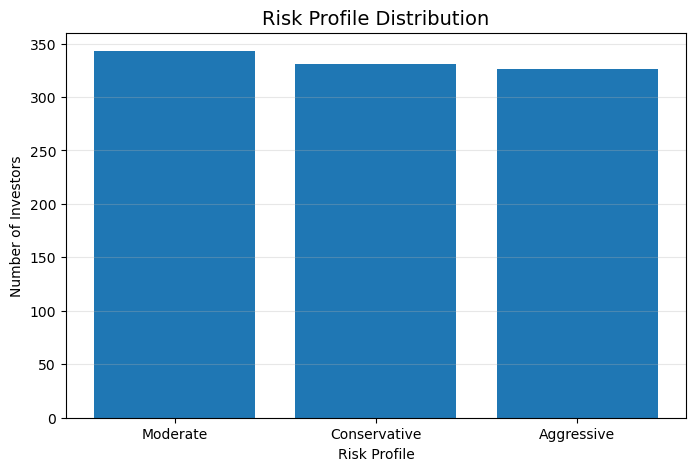

In [22]:
risk_count = investors["Risk_Profile"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(risk_count.index, risk_count.values)

plt.title("Risk Profile Distribution", fontsize=14)
plt.xlabel("Risk Profile")
plt.ylabel("Number of Investors")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [34]:
print(investors.columns.tolist())

['Investor_ID', 'Gender', 'Age', 'Marital_Status', 'Occupation', 'Annual_Income', 'City', 'State', 'Risk_Profile', 'Investment_Goal', 'Investment_Horizon_Years', 'Investor_Segment']


In [41]:
# Export cleaned data

investors.to_csv("investors_clean.csv", index=False)

funds.to_csv("funds_clean.csv", index=False)

transactions.to_csv("transactions_clean.csv", index=False)

print("Files exported successfully!")

Files exported successfully!


In [42]:
print(funds.columns.tolist())

['Fund_ID', 'Fund_Name', 'Fund_Category', 'AMC', 'Expected_Return_%']


In [43]:
print(transactions.columns.tolist())

['Transaction_ID', 'Investor_ID', 'Date', 'Fund_ID', 'Fund_Name', 'SIP_Amount', 'NAV', 'Units_Allocated']


In [44]:
import pandas as pd

df = pd.read_csv("transactions_clean.csv")

print(df.head())
print(df.shape)

  Transaction_ID Investor_ID        Date Fund_ID                    Fund_Name  \
0      TXN000001     INV0001  2025-01-01    F002  Parag Parikh Flexi Cap Fund   
1      TXN000002     INV0001  2025-02-01    F002  Parag Parikh Flexi Cap Fund   
2      TXN000003     INV0001  2025-03-01    F002  Parag Parikh Flexi Cap Fund   
3      TXN000004     INV0001  2025-04-01    F002  Parag Parikh Flexi Cap Fund   
4      TXN000005     INV0001  2025-05-01    F002  Parag Parikh Flexi Cap Fund   

   SIP_Amount     NAV  Units_Allocated  
0       20000  166.81         119.8969  
1       20000   94.04         212.6755  
2       20000  174.14         114.8501  
3       20000  173.00         115.6069  
4       20000  169.27         118.1544  
(12000, 8)


In [46]:
funds = funds.rename(columns={
    "Expected_Return_%": "Expected_Return"
})

funds.to_csv("funds_clean.csv", index=False)

print(funds.columns)

Index(['Fund_ID', 'Fund_Name', 'Fund_Category', 'AMC', 'Expected_Return'], dtype='object')
